In [1]:
from mtpy.modeling import StructuredGrid3D
from pathlib import Path
import numpy as np
from mtpy.core.mt_location import MTLocation
from mtpy.core.mt_stations import MTStations
from mtpy import MT, MTData

In [2]:
nw = MTLocation(latitude=34, longitude=-122, utm_epsg=32610)
se = MTLocation(latitude=33.0, longitude=-120.5, utm_epsg=32610)

In [3]:
dx = int(abs(nw.east - se.east) / 10000)
dy = int(abs(nw.north - se.north) / 10000)

In [4]:
x = np.linspace(nw.longitude, se.longitude, num=dx)
y = np.linspace(nw.latitude, se.latitude, num=dy)

In [5]:
md = MTData()
count = 1
for xx in x:
    for yy in y:
        mt = MT()
        mt.longitude = xx
        mt.latitude = yy
        # mt.utm_epsg = 32610
        mt.station = f"MT{count:003}"
        md.add_station(mt, survey="data")
        count += 1

In [6]:
len(md.keys())

140

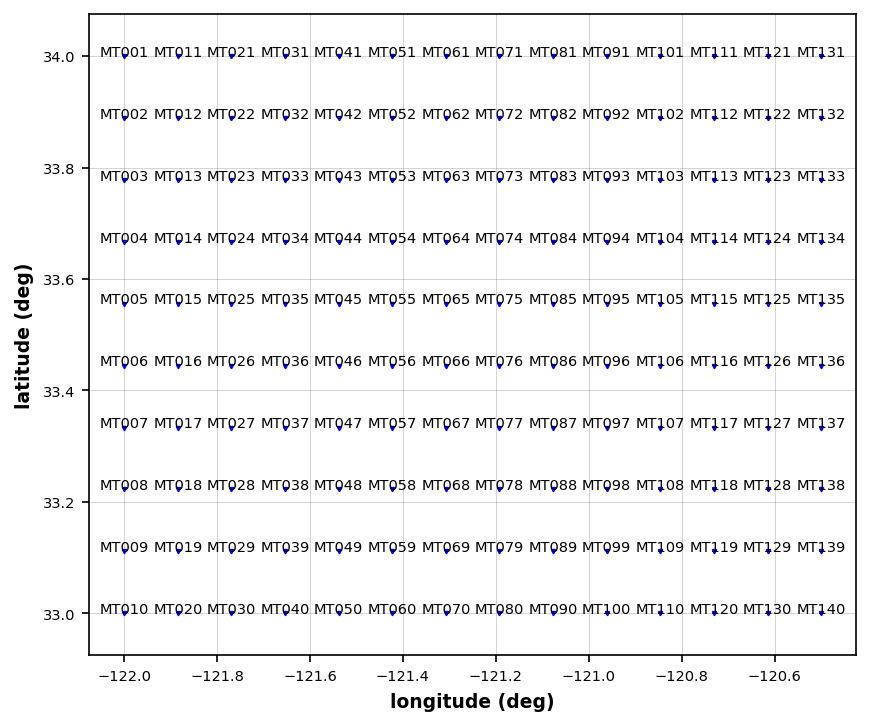

Plotting PlotStations

In [7]:
md.plot_stations()


In [8]:
md.utm_epsg = 32610
md.compute_relative_locations()

In [9]:
s = StructuredGrid3D()
s.station_locations = md.station_locations
s.center_point = md.center_point
s.cell_size_east = 2000
s.cell_size_north = 2000
s.n_layers = 50
s.n_air_layers = 0
s.model_epsg = 32610

In [10]:
s.center_point

MT Location: 
--------------------
  Latitude (deg):   33.502308
  Longitude (deg):  -121.245643
  Elevation (m):    0.0000
  Datum crs:        EPSG:4326

  Easting (m):      662959.783
  Northing (m):     3708352.450
  UTM crs:          EPSG:32610

  Model Easting (m):      662959.783
  Model Northing (m):     3708352.450
  Model Elevation (m):    0.000
  Profile Offset (m):     0.000

25:10:28T12:13:48 | WARNING | line:1747 |mtpy.modeling.structured_mesh_3d | _validate_extent | Provided or default ew_ext not sufficient to fit stations + padding, updating extent
25:10:28T12:13:48 | WARNING | line:1753 |mtpy.modeling.structured_mesh_3d | _validate_extent | Provided or default ns_ext not sufficient to fit stations + padding, updating extent
Structured3DMesh Model Object:
--------------------
	Number of stations = 140
	Mesh Parameter: 
		cell_size_east:    2000
		cell_size_north:   2000
		pad_east:          7
		pad_north:         7
		pad_num:           3
		z1_layer:          10
		z_target_depth:    50000
		n_layers:          50
		n_air_layers:      0
		res_initial_value: 100.0
	Dimensions: 
		e-w: 96
		n-s: 80
		z:   51 (without 7 air layers)
	Extensions: 
		e-w:  326000.0 (m)
		n-s:  258000.0 (m)
		0-z:  93497.0 (m)
--------------------
25:10:28T12:13:48 | WARNING | line:49 |mtpy.modeling.plots.plot_mesh | _plot_topography | Cannot find topography information, skipping

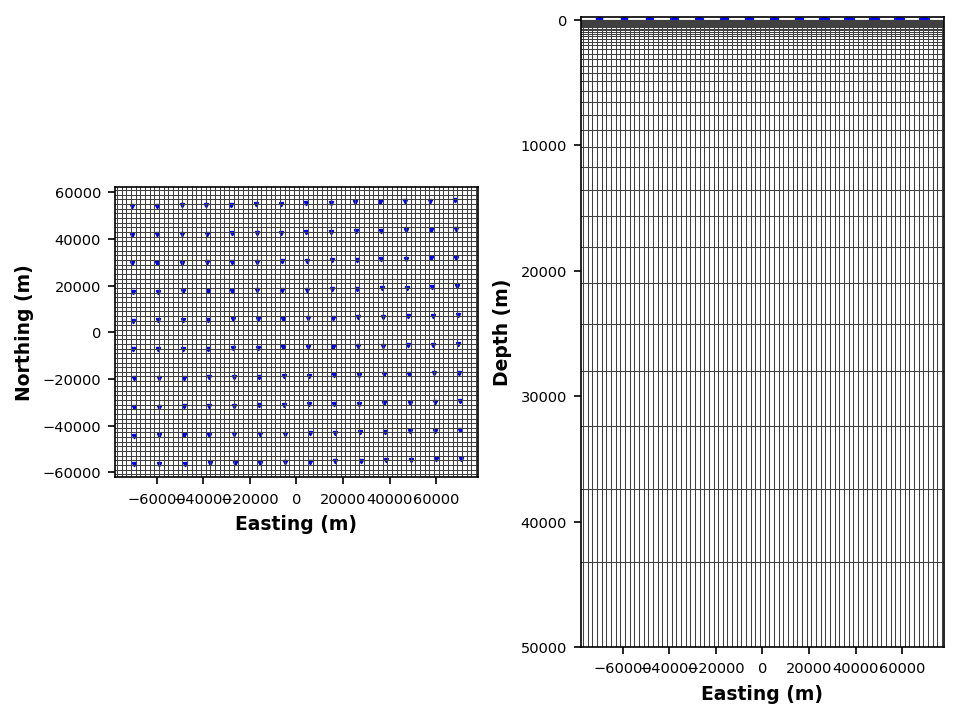

Plotting PlotMesh

In [11]:
s.make_mesh()
s.plot_mesh()

In [14]:
s.add_topography_to_model(topography_file=Path(r"c:\\Users\\peaco\\Downloads\\exportImage.tiff"))

Read geotiff surface file
25:10:28T12:14:16 | WARNING | line:1620 |mtpy.modeling.structured_mesh_3d | add_topography_to_model | No air layers specified, so will not add air/topography !!!
25:10:28T12:14:16 | WARNING | line:1623 |mtpy.modeling.structured_mesh_3d | add_topography_to_model | Only bathymetry will be added below according to the topofile: sea-water low resistivity!!!


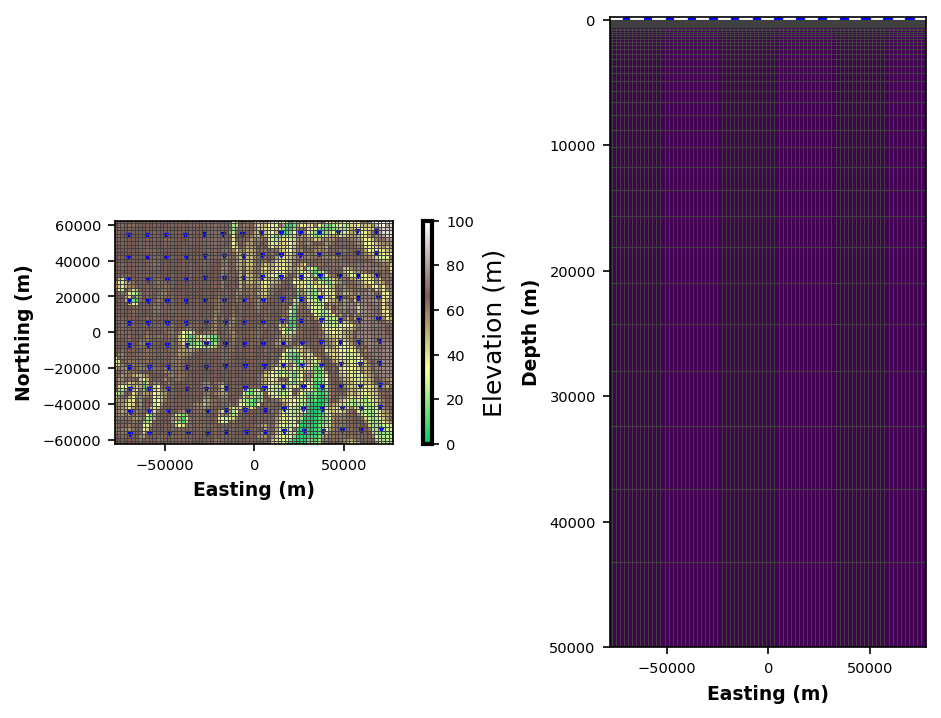

Plotting PlotMesh

In [15]:
s.plot_mesh()